# Session 8 — Output Analysis for Terminating Simulations

**Course:** Decision Modelling — Simulation Part
**Session:** 8 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- Conduct replication-based analysis of a terminating simulation
- Estimate the number of replications required for a target precision
- Interpret output from terminating simulations correctly

## Format note: flipped classroom

This session follows a **flipped-classroom** structure:

- **Pre-class (screencast + this notebook's Part A):** build a new SimPy model — a multi-stage terminating system with a closing-time rule. Watch the screencast and run Part A yourself before class.
- **In-class (Part B):** we do *not* re-teach the SimPy code. Class time is spent entirely on the statistical core of this session — why a single run isn't enough, how to build a proper confidence interval from replications, and how to determine how many replications you actually need. Bring your Part A results with you.

## Where this session fits

- **Looking back:** Sessions 6–7 built single- and multi-server queues and ran each **once**. We've flagged repeatedly that a single run is just one noisy realization — this session finally fixes that properly, the same way Sessions 3–4 did for Monte Carlo.
- **New SimPy feature today:** a **multi-stage process** (an entity passes through more than one resource in sequence) and a **conditional arrival cutoff** (new arrivals stop after a closing time, but the system keeps running until everyone already inside has finished) — the defining structure of a *terminating* simulation.
- **Looking ahead:** Session 9 handles the *other* kind of simulation — systems with no natural ending (steady-state) — which needs different techniques (warm-up, batch means) because the "run many independent replications" trick from today doesn't transfer directly.


## Further reading (supplementary, not required)

- A chapter or paper on replication-based output analysis for terminating simulations, and on the two-stage procedure for determining the number of replications needed for a target confidence-interval precision — check the course reading list for the current reference.


---
# Part A (pre-class): a multi-stage, terminating SimPy model

Watch the accompanying screencast for a walkthrough of the code below, then run it yourself before class.

## What makes a simulation "terminating"?

A **terminating simulation** has a natural, well-defined ending event — a specific point in time or a specific condition that stops the simulation, after which we report on what happened *during that one run*. Examples: a shop's business day (closes at a fixed time), a project (ends when the last task finishes), a one-time event (a conference registration desk, open only during the conference). This is different from a system that could in principle run forever (Session 9's steady-state systems).

## Today's model: a small clinic with a closing-time rule

- **Stage 1 — Check-in:** one clerk
- **Stage 2 — Consultation:** two doctors
- **Business hours:** the clinic is open for `540` minutes (9 hours). **New patients stop arriving at closing time — but any patient already inside keeps moving through check-in and consultation until they're done.** This conditional cutoff is the defining feature of a terminating model.


In [1]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def patient(env, name, checkin, doctors, rng, records):
    arrival_time = env.now

    with checkin.request() as req:
        yield req
        checkin_wait = env.now - arrival_time
        yield env.timeout(rng.exponential(3.0))   # check-in takes ~3 minutes on average
    checkin_done_time = env.now

    with doctors.request() as req:
        yield req
        consult_wait = env.now - checkin_done_time
        yield env.timeout(rng.exponential(12.0))  # consultation takes ~12 minutes on average
    departure_time = env.now

    records.append({
        'name': name,
        'arrival_time': arrival_time,
        'checkin_wait': checkin_wait,
        'consult_wait': consult_wait,
        'total_wait': checkin_wait + consult_wait,
        'time_in_system': departure_time - arrival_time,
    })

def patient_generator(env, mean_interarrival, closing_time, checkin, doctors, rng, records):
    patient_id = 0
    while True:
        interarrival = rng.exponential(mean_interarrival)
        if env.now + interarrival >= closing_time:
            break   # stop generating new patients once we'd pass closing time
        yield env.timeout(interarrival)
        patient_id += 1
        env.process(patient(env, patient_id, checkin, doctors, rng, records))


In [2]:
def run_one_day(mean_interarrival, closing_time, seed):
    rng = np.random.default_rng(seed)
    env = simpy.Environment()
    checkin = simpy.Resource(env, capacity=1)
    doctors = simpy.Resource(env, capacity=2)
    records = []

    env.process(patient_generator(env, mean_interarrival, closing_time, checkin, doctors, rng, records))
    # Run well beyond closing time so every admitted patient can finish
    env.run(until=closing_time + 500)

    return pd.DataFrame(records)

# Try a single day
df_day = run_one_day(mean_interarrival=8.0, closing_time=540, seed=1)
print(f"Patients served: {len(df_day)}")
print(f"Mean total wait time: {df_day['total_wait'].mean():.2f} minutes")
print(f"Last patient departs at simulated time: {df_day['time_in_system'].add(df_day['arrival_time']).max():.1f} "
      f"(closing time was {540})")
df_day.head()


Patients served: 52
Mean total wait time: 3.05 minutes
Last patient departs at simulated time: 557.8 (closing time was 540)


,name,arrival_time,checkin_wait,consult_wait,total_wait,time_in_system
0,2,11.051857,13.658685,0.000000,13.658685,15.669511
1,1,8.584232,0.000000,0.000000,0.000000,22.109980
2,4,14.906171,13.750836,1.345399,15.096235,25.223108
3,3,13.983274,12.381533,0.000000,12.381533,27.171233
4,5,29.304547,0.044265,10.154616,10.198881,12.369861


Notice the last patient can depart **well after** the official closing time — this is exactly right for a terminating model: the clinic stops *admitting* new patients at closing, but must still finish everyone already inside. If you only ran the simulation *until* `closing_time` and stopped, you'd be cutting off patients mid-consultation, which would bias your results.

Part A is done here — the rest of this notebook (Part B) is for class.


---
# Part B (in-class): replications, confidence intervals, and sample size

## 1. Why one simulated day isn't enough

`run_one_day()` above gives us **one realization** of a random process — one particular day's worth of random interarrival and service times. A different `seed` would give a different, equally valid, "day":


In [3]:
for seed in [1, 2, 3, 4, 5]:
    df_seed = run_one_day(mean_interarrival=8.0, closing_time=540, seed=seed)
    print(f"seed={seed}: patients served = {len(df_seed):3d}, mean total wait = {df_seed['total_wait'].mean():6.2f} min")


seed=1: patients served =  52, mean total wait =   3.05 min
seed=2: patients served =  88, mean total wait =  20.85 min
seed=3: patients served =  53, mean total wait =   8.48 min
seed=4: patients served =  55, mean total wait =  15.54 min
seed=5: patients served =  63, mean total wait =   8.90 min


Both the number of patients served and the mean wait time bounce around from day to day. **Neither a single day's number, nor an arbitrarily chosen day, tells us what the clinic's typical performance looks like.** This is exactly the Monte Carlo replication idea from Sessions 3–4 — but now each "replication" is an entire terminating simulation run (one simulated business day) rather than one draw from a demand distribution.


## 2. Replications and confidence intervals

The fix is the same one you already know: run **many independent replications** (different random number streams — here, different seeds), treat each replication's summary statistic (e.g. mean wait time for that day) as one data point, and build a confidence interval across replications.

**Important distinction:** within a single replication, individual patients' wait times are *not* independent of each other (a busy morning affects everyone that morning). But the **daily averages across different replications** *are* independent, since each replication uses fresh, unrelated randomness. This is why we compute one summary number *per replication*, not per patient, when building the CI — mixing up "per-patient" and "per-replication" variability is one of the most common mistakes in simulation output analysis.


In [4]:
def run_replications(n_reps, mean_interarrival, closing_time, base_seed=1000):
    daily_means = []
    daily_counts = []
    for i in range(n_reps):
        df_i = run_one_day(mean_interarrival, closing_time, seed=base_seed + i)
        daily_means.append(df_i['total_wait'].mean())
        daily_counts.append(len(df_i))
    return np.array(daily_means), np.array(daily_counts)

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    sem = data.std(ddof=1) / np.sqrt(n)
    half_width = stats.t.ppf((1 + confidence) / 2, df=n - 1) * sem
    return mean, half_width

n_reps = 20
daily_means, daily_counts = run_replications(n_reps, mean_interarrival=8.0, closing_time=540)

mean_of_means, half_width = confidence_interval(daily_means)
print(f"Across {n_reps} replications:")
print(f"Point estimate of mean daily wait time: {mean_of_means:.2f} minutes")
print(f"95% CI half-width: {half_width:.2f} minutes")
print(f"95% CI: [{mean_of_means - half_width:.2f}, {mean_of_means + half_width:.2f}]")


Across 20 replications:
Point estimate of mean daily wait time: 12.67 minutes
95% CI half-width: 5.91 minutes
95% CI: [6.76, 18.58]


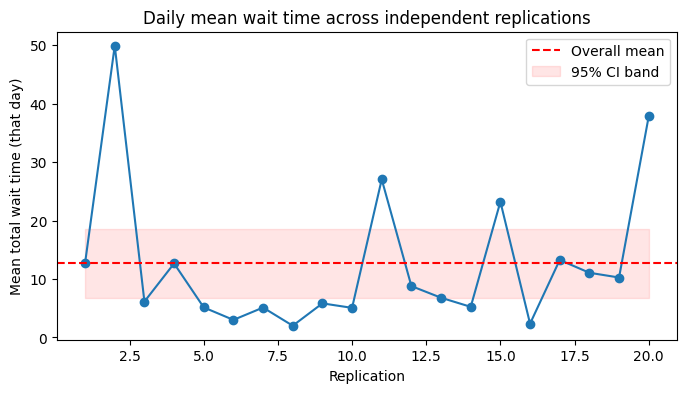

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, n_reps + 1), daily_means, 'o-')
plt.axhline(mean_of_means, color='red', linestyle='--', label='Overall mean')
plt.fill_between(range(1, n_reps + 1), mean_of_means - half_width, mean_of_means + half_width,
                  color='red', alpha=0.1, label='95% CI band')
plt.xlabel('Replication')
plt.ylabel('Mean total wait time (that day)')
plt.title('Daily mean wait time across independent replications')
plt.legend()
plt.show()


## 3. How many replications do we actually need?

So far we picked `n_reps = 20` arbitrarily — exactly the kind of round-number guess Session 3 warned against. There's a principled way to choose `n`, based on how precise you need your estimate to be.

**The two-stage procedure:**

1. Run a small **pilot** batch of `n0` replications; compute the sample standard deviation `s0` of the per-replication statistic.
2. Decide on a desired **absolute half-width** `e` for your final confidence interval (e.g. "I want to know mean wait time to within +/-2 minutes").
3. Estimate the required total number of replications:

```
n  ~=  ( t(n0-1, 1-alpha/2) * s0 / e )^2
```

4. Since the t-value itself depends on the (unknown, final) `n`, this is solved **iteratively**: start with a guess (e.g. using the normal `z` critical value instead of `t`), compute `n`, then recompute the required `t` using that `n`, and repeat until `n` stops changing.


In [6]:
def required_replications(pilot_data, target_half_width, confidence=0.95, max_iter=20):
    n0 = len(pilot_data)
    s0 = pilot_data.std(ddof=1)

    n_est = n0  # initial guess
    for _ in range(max_iter):
        t_crit = stats.t.ppf((1 + confidence) / 2, df=max(n_est - 1, 1))
        n_new = int(np.ceil((t_crit * s0 / target_half_width) ** 2))
        if n_new == n_est:
            break
        n_est = n_new
    return n_est, s0

pilot_means, _ = run_replications(n_reps=10, mean_interarrival=8.0, closing_time=540, base_seed=1)
target_half_width = 2.0  # minutes

n_required, s0 = required_replications(pilot_means, target_half_width)
print(f"Pilot std dev (s0): {s0:.3f}")
print(f"Replications needed for a 95% CI half-width of {target_half_width} minutes: {n_required}")


Pilot std dev (s0): 11.351
Replications needed for a 95% CI half-width of 2.0 minutes: 127


Let's now run the *required* number of replications and confirm we actually achieve (approximately) the target precision.


In [7]:
final_means, final_counts = run_replications(n_required, mean_interarrival=8.0, closing_time=540, base_seed=1)
final_mean, final_half_width = confidence_interval(final_means)

print(f"With n={n_required} replications:")
print(f"Point estimate: {final_mean:.2f} minutes")
print(f"95% CI half-width achieved: {final_half_width:.2f} minutes  (target was {target_half_width})")


With n=127 replications:
Point estimate: 13.92 minutes
95% CI half-width achieved: 1.89 minutes  (target was 2.0)


### Discussion: why might the achieved half-width not exactly match the target?

The pilot's `s0` is itself just an *estimate* of the true variability, based on only `n0` replications. If the pilot happened to underestimate or overestimate variability, the final achieved half-width will be a bit off from the target. This is a good moment to connect back to Session 2: `s0` is subject to exactly the same kind of sampling uncertainty as any other statistic estimated from finite data.


## Exercise (guided): a tighter precision target, and a policy question

Management wants to know the mean **number of patients served per day** to within **+/- 1 patient** (95% confidence) — not wait time this time.

Your task:

1. Run a pilot batch of replications and extract `daily_counts` (number of patients served) instead of `daily_means`
2. Use `required_replications()` to determine how many replications are needed for a half-width of 1 patient
3. Run that many replications and report the final point estimate and CI
4. Separately: management is considering increasing `mean_interarrival` slightly (fewer patients booked per day) to reduce wait times. Using the *same replication count* you just determined, compare mean total wait time at `mean_interarrival=8.0` vs `mean_interarrival=9.0`, and report both CIs


In [8]:
# EXERCISE
# TODO: 1. Run a pilot batch (e.g. n0=10) and get daily_counts
# TODO: 2. Determine required replications for a target half-width of 1 patient
# TODO: 3. Run that many replications; report point estimate + CI for patients served
# TODO: 4. Compare mean total wait time at mean_interarrival=8.0 vs 9.0, using the same n


<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
_, pilot_counts = run_replications(n_reps=10, mean_interarrival=8.0, closing_time=540, base_seed=1)

n_required_counts, s0_counts = required_replications(pilot_counts, target_half_width=1.0)
print(f"Replications needed for patients-served half-width of 1: {n_required_counts}")

_, final_counts = run_replications(n_required_counts, mean_interarrival=8.0, closing_time=540, base_seed=1)
mean_count, hw_count = confidence_interval(final_counts)
print(f"Mean patients served: {mean_count:.2f}  (95% CI half-width: {hw_count:.2f})")

means_8, _ = run_replications(n_required_counts, mean_interarrival=8.0, closing_time=540, base_seed=2000)
means_9, _ = run_replications(n_required_counts, mean_interarrival=9.0, closing_time=540, base_seed=2000)

mean_8, hw_8 = confidence_interval(means_8)
mean_9, hw_9 = confidence_interval(means_9)

print(f"\nmean_interarrival=8.0: mean wait = {mean_8:.2f}  (95% CI half-width: {hw_8:.2f})")
print(f"mean_interarrival=9.0: mean wait = {mean_9:.2f}  (95% CI half-width: {hw_9:.2f})")
```
</details>


### Discussion questions

1. Why does it make sense to determine the *number of replications* separately for "wait time" and "patients served" — could the same `n` serve both precision targets equally well?
2. If the two mean_interarrival scenarios' confidence intervals for wait time don't overlap, what can you conclude? If they do overlap, what would you need to do to compare them more precisely? (Think back to Session 4.)
3. Suppose a colleague ran only `n0=3` pilot replications before applying the two-stage procedure. What could go wrong with the resulting `n_required`?


## Wrap-up

Today (Part A, pre-class) we:

- Built a multi-stage (check-in -> consultation) terminating simulation model
- Introduced a conditional arrival cutoff — the defining SimPy pattern for terminating systems (stop admitting, keep processing)

Today (Part B, in-class) we:

- Established why a single terminating simulation run is just one noisy realization, exactly like a single Monte Carlo replication
- Built proper replication-based confidence intervals, being careful to summarize *per replication*, not per entity
- Applied the two-stage procedure to determine how many replications are needed for a target precision, rather than guessing a round number
- Practiced the full workflow on a new metric and used it to make a scenario comparison

**Next session:** Output Analysis for Steady-State Simulations — not every system has a natural closing time. We'll introduce **process interrupts** (modeling machine breakdowns) and learn why the "many independent replications" trick from today needs to be replaced with warm-up detection and batch means for systems that run indefinitely.
